In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

print("Features:", X.shape)
print("Target:", y.shape)

# Display first five rows
df = pd.DataFrame(X, columns=data.feature_names)
df["Target"] = y

print(df.head())

Features: (569, 30)
Target: (569,)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst peri

In [3]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Standardization

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4]:
mle_model = LogisticRegression(
    penalty=None,
    max_iter=5000
)

mle_model.fit(X_train, y_train)

mle_pred = mle_model.predict(X_test)

print("MLE Accuracy")
print(accuracy_score(y_test, mle_pred))

print(classification_report(y_test, mle_pred))

MLE Accuracy
0.9385964912280702
              precision    recall  f1-score   support

           0       0.88      0.98      0.92        43
           1       0.98      0.92      0.95        71

    accuracy                           0.94       114
   macro avg       0.93      0.95      0.94       114
weighted avg       0.94      0.94      0.94       114



In [5]:
map_l2 = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=5000
)

map_l2.fit(X_train, y_train)

pred_l2 = map_l2.predict(X_test)

print("MAP (L2) Accuracy")
print(accuracy_score(y_test, pred_l2))

MAP (L2) Accuracy
0.9736842105263158


In [6]:
map_l1 = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=1.0,
    max_iter=5000
)

map_l1.fit(X_train, y_train)

pred_l1 = map_l1.predict(X_test)

print("MAP (L1) Accuracy")
print(accuracy_score(y_test, pred_l1))

MAP (L1) Accuracy
0.9736842105263158


In [7]:
comparison = pd.DataFrame({
    "Feature": data.feature_names,
    "MLE": mle_model.coef_[0],
    "MAP_L2": map_l2.coef_[0],
    "MAP_L1": map_l1.coef_[0]
})

print(comparison)

                    Feature         MLE    MAP_L2    MAP_L1
0               mean radius   18.674433 -0.427896  0.000000
1              mean texture  -38.770421 -0.393913  0.000000
2            mean perimeter   85.863999 -0.389550  0.000000
3                 mean area   21.825723 -0.464316  0.000000
4           mean smoothness    9.945701 -0.066754  0.000000
5          mean compactness  599.625747  0.542106  0.000000
6            mean concavity -292.316154 -0.796771  0.000000
7       mean concave points -579.850455 -1.117021 -2.385181
8             mean symmetry   88.153394  0.235713  0.023437
9    mean fractal dimension -367.904097  0.076701  0.000000
10             radius error -566.490524 -1.271147 -2.475849
11            texture error   78.567689  0.188640  0.377182
12          perimeter error  253.553102 -0.609366  0.000000
13               area error -364.748996 -0.909800  0.000000
14         smoothness error -170.576094 -0.312461 -0.427645
15        compactness error -213.950199 

In [8]:
print("MLE Accuracy :", accuracy_score(y_test, mle_pred))
print("MAP L2 Accuracy :", accuracy_score(y_test, pred_l2))
print("MAP L1 Accuracy :", accuracy_score(y_test, pred_l1))

MLE Accuracy : 0.9385964912280702
MAP L2 Accuracy : 0.9736842105263158
MAP L1 Accuracy : 0.9736842105263158


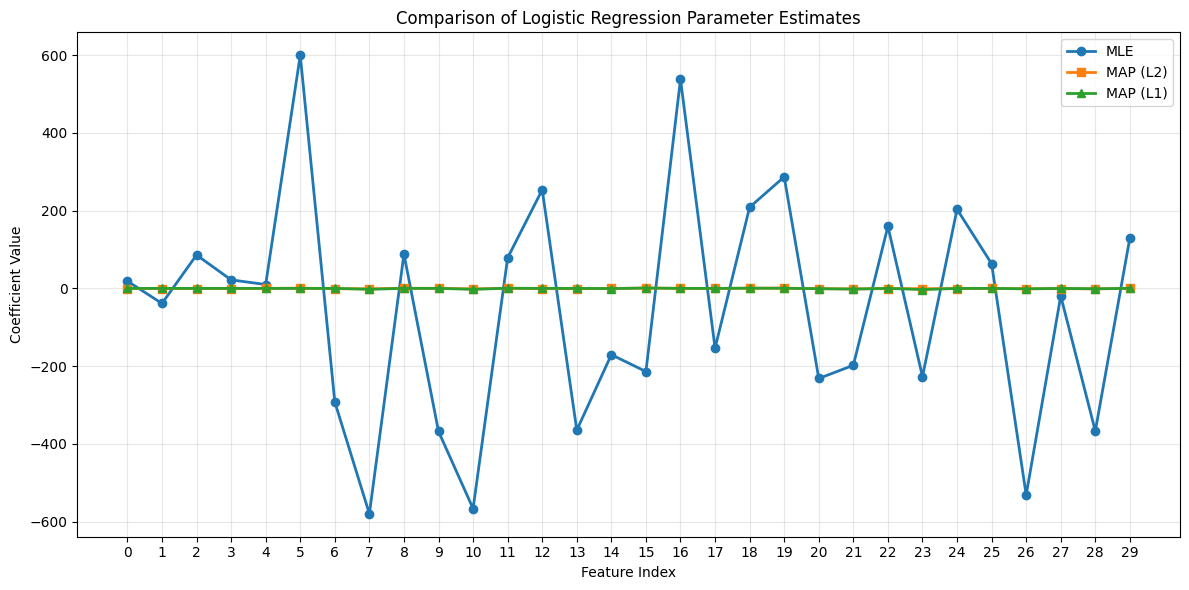

In [10]:
# Estimated parameters
mle_params = mle_model.coef_[0]
l2_params = map_l2.coef_[0]
l1_params = map_l1.coef_[0]

# Feature indices
features = np.arange(len(mle_params))

plt.figure(figsize=(12,6))

plt.plot(features, mle_params, 'o-', linewidth=2, label='MLE')
plt.plot(features, l2_params, 's-', linewidth=2, label='MAP (L2)')
plt.plot(features, l1_params, '^-', linewidth=2, label='MAP (L1)')

plt.title("Comparison of Logistic Regression Parameter Estimates")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.xticks(features)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

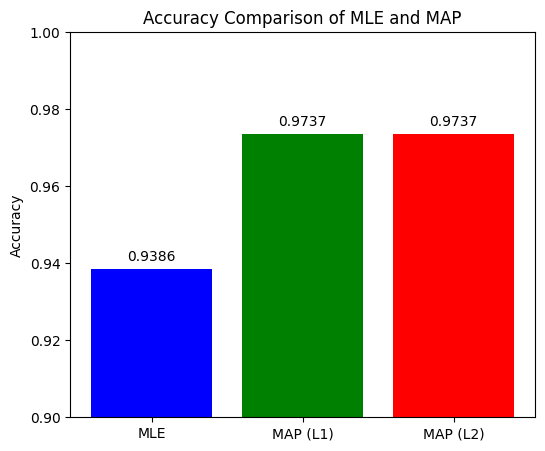

In [11]:
import matplotlib.pyplot as plt

# Accuracy values
accuracies = [
    accuracy_score(y_test, mle_pred),
    accuracy_score(y_test, pred_l1),
    accuracy_score(y_test, pred_l2)
]

models = ['MLE', 'MAP (L1)', 'MAP (L2)']

plt.figure(figsize=(6,5))
bars = plt.bar(models, accuracies, color=['blue','green','red'])

plt.ylim(0.9,1.0)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of MLE and MAP")

# Display accuracy values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval + 0.002,
             f"{yval:.4f}",
             ha='center')

plt.show()